In [5]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 


Library numpy untuk membantu manipulasi array dan matriks. Library matplotlib.pyplot untuk menampilkan hasil citra ke dalam bentuk visual. library cv2. untuk membaca file gambar, mengubah format warna, melakukan transformasi citra, serta berbagai operasi lain seperti filtering, deteksi objek, dan manipulasi piksel.

Text(0.5, 1.0, 'gambarB')

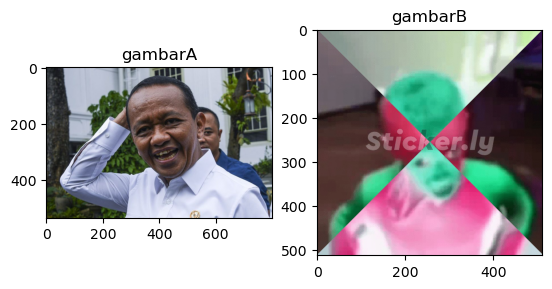

In [6]:
img1 = plt.imread("Assets/bahlul.jpg")

plt.subplot(1,2,1)
plt.imshow(img1)
plt.title("gambarA")

img2 = plt.imread("Assets/robby_negatif.jpg")

plt.subplot(1,2,2)
plt.imshow(img2)
plt.title("gambarB")

kode ini untuk menampilkan gambar di file Assets menggunakan plt.imread yang dibaca dan ditampilkan seraca RGB

In [7]:
def operasi_negatif_diagonal(img_bgr):

    img = img_bgr.copy().astype(np.int32)
    H, W = img.shape[:2]

    rows = np.arange(H).reshape(H, 1)   
    cols = np.arange(W).reshape(1, W)   

    r_norm = rows / H  
    c_norm = cols / W  

    diag_utama = r_norm > c_norm           
    anti_diag  = (r_norm + c_norm) < 1   

    mask = np.logical_xor(diag_utama, anti_diag) 

    for ch in range(3):
        img[:, :, ch][mask] = 255 - img[:, :, ch][mask]

    return img.astype(np.uint8), mask

Fungsi ini menerapkan efek negatif secara selektif hanya pada area tertentu gambar yang membentuk pola 4 segitiga di sudut, bukan pada seluruh gambar.

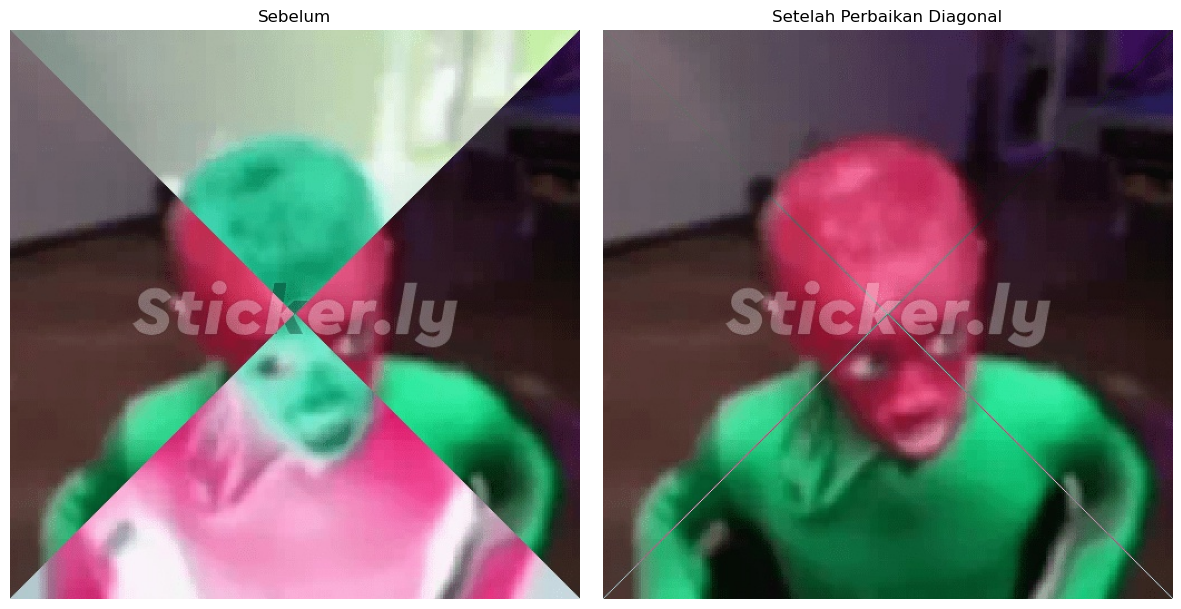

In [27]:
img2 = cv2.imread("Assets/robby_negatif.jpg")

if img2 is None:
    print("Gagal memuat gambar! Periksa kembali apakah file ada di folder Assets/")
else:
    img_hasil_bgr, mask_diagonal = operasi_negatif_diagonal(img2)

    img_asli_rgb = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)
    img_hasil_rgb = cv2.cvtColor(img_hasil_bgr, cv2.COLOR_BGR2RGB)

    plt.figure(figsize=(12, 6))

    plt.subplot(1, 2, 1)
    plt.imshow(img_asli_rgb)
    plt.title("Sebelum")
    plt.axis('off')

    plt.subplot(1, 2, 2)
    plt.imshow(img_hasil_rgb)
    plt.title("Setelah Perbaikan Diagonal")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

kode tersebut dimulai dari membaca gambar dalam format BGR menggunakan cv2. kemudian mengecek apakah gambar berhasil dimuat. cv2.imread mengembalikan None jika file gambar tidak ditemukan. 
Jika gambar berhasil dimuat, jalankan fungsi operasi_negatif_diagonal dan unpack hasilnya menjadi 2 variabel yaitu img_hasil_bgr dan mask_diagonal. kemudian mengorversinya menjadi format dari bgr ke rgb kemudian ditampilkan dengan imshow.

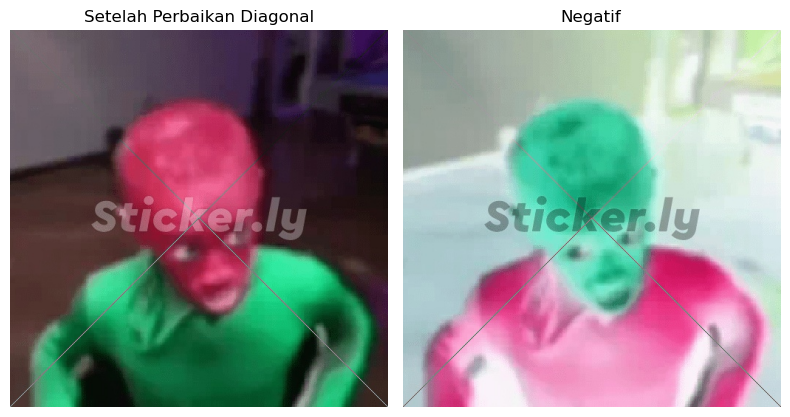

In [44]:
h, w, c     = img_hasil_rgb.shape
img_negatif = np.zeros((h, w, c), dtype=img_hasil_rgb.dtype)

for i in range(h):
    for j in range(w):
        img_negatif[i, j, 2] = 255 - img_hasil_rgb[i, j, 2]  # R
        img_negatif[i, j, 1] = 255 - img_hasil_rgb[i, j, 1]  # G
        img_negatif[i, j, 0] = 255 - img_hasil_rgb[i, j, 0]  # B

plt.figure(figsize=(8, 5))

plt.subplot(1, 2, 1)
plt.imshow(img_hasil_rgb)
plt.title("Setelah Perbaikan Diagonal")
plt.axis('off')


plt.subplot(1, 2, 2)
plt.imshow(img_negatif)
plt.title("Negatif")
plt.axis('off')

plt.tight_layout()
plt.show()

membuat kanvas kosong dengan ukuran yang sama dengan img_hasil_rgb yang diberi nama img_negatif. kemudian menukar posisi channel dan mengurangi dengan 255 dan menampilkan dengan imshow.

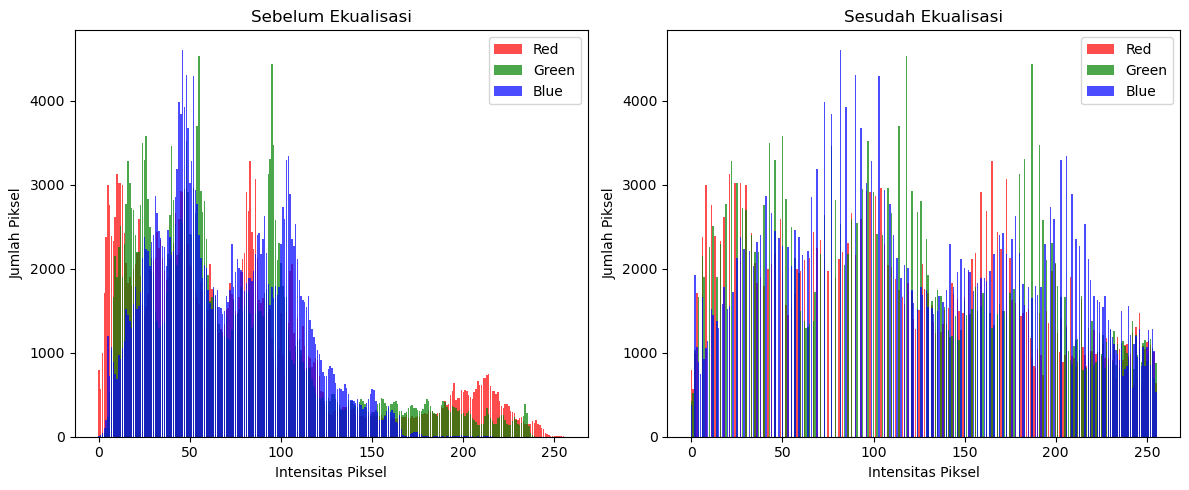

In [ ]:
def plot_histogram(histogram, title, ImgColor, new_figure=True):
    if new_figure:
        plt.figure(figsize=(10, 5))
    plt.xlabel("Intensitas Piksel")
    plt.title(title)
    plt.ylabel("Jumlah Piksel")
    plt.bar(range(256), histogram, color=ImgColor, width=0.8, alpha=0.7, label=title)

def ekualisasi_channel(channel):
    h, w  = channel.shape
    total = h * w

    hist = np.zeros(256, dtype=np.int32)
    for i in range(h):
        for j in range(w):
            hist[channel[i, j]] += 1

    cdf    = np.zeros(256, dtype=np.int32)
    cdf[0] = hist[0]
    for i in range(1, 256):
        cdf[i] = cdf[i-1] + hist[i]

    cdf_min = cdf[cdf > 0].min()
    lut     = np.zeros(256, dtype=np.uint8)
    for i in range(256):
        if cdf[i] > 0:
            lut[i] = round((cdf[i] - cdf_min) / (total - cdf_min) * 255)

    hasil = np.zeros((h, w), dtype=np.uint8)
    for i in range(h):
        for j in range(w):
            hasil[i, j] = lut[channel[i, j]]

    return hasil, hist

h, w, c   = img_hasil_rgb.shape
img_ekual = np.zeros((h, w, c), dtype=np.uint8)

hist_sebelum = []
hist_sesudah = []

for k in range(c):
    channel            = img_hasil_rgb[:, :, k]
    hasil, hist        = ekualisasi_channel(channel)
    img_ekual[:, :, k] = hasil

    hist_sebelum.append(hist)

    hist_s = np.zeros(256, dtype=np.int32)
    for i in range(h):
        for j in range(w):
            hist_s[hasil[i, j]] += 1
    hist_sesudah.append(hist_s)

warna = ['red', 'green', 'blue']
label = ['Red', 'Green', 'Blue']

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
for k in range(c):
    plot_histogram(hist_sebelum[k], label[k], warna[k], new_figure=False)
plt.title("Sebelum Ekualisasi")
plt.legend()

plt.subplot(1, 2, 2)
for k in range(c):
    plot_histogram(hist_sesudah[k], label[k], warna[k], new_figure=False)
plt.title("Sesudah Ekualisasi")
plt.legend()

plt.tight_layout()
plt.show()

Fungsi plot_histogram untuk menggambar histogram dalam bentuk bar chart. Parameter new_figure membuatnya fleksibel dan jika True akan membuat figure baru sendiri, jika False akan menggambar di subplot yang sudah ada. Ini penting karena dalam kode ini fungsi dipanggil berkali-kali dalam satu subplot untuk menggambar 3 channel sekaligus. Fungsi ekualisasi_channel untuk menerima satu channel gambar (2D array) dan mengembalikan hasil ekualisasi beserta histogram aslinya. Gambar img_hasil_rgb diproses channel per channel (R, G, B secara terpisah) menggunakan ekualisasi_channel. Hasil tiap channel digabung kembali ke img_ekual. Histogram sebelum diambil langsung dari return fungsi, sedangkan histogram sesudah dihitung ulang secara manual dari hasil ekualisasi  kemudian ditampilkan dengan imshow hasil dari sebelum dan sesudah.

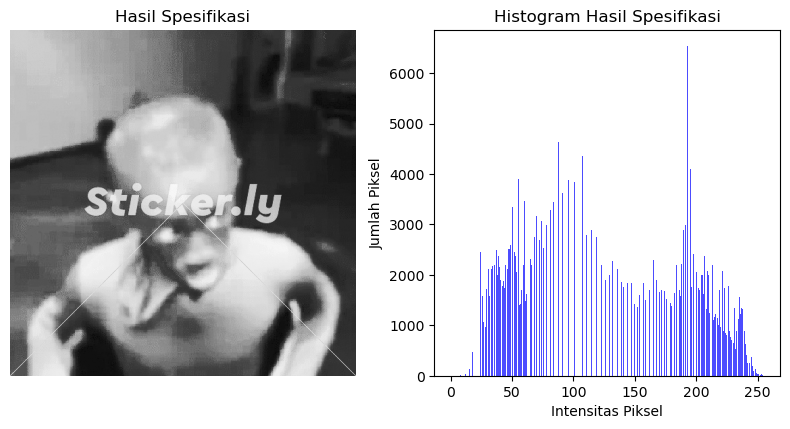

In [46]:
def spesifikasi_histogram(citra_asal, citra_target):
    hist_asal   = np.zeros(256, dtype=int)
    hist_target = np.zeros(256, dtype=int)

    for i in range(citra_asal.shape[0]):
        for j in range(citra_asal.shape[1]):
            hist_asal[citra_asal[i][j]] += 1

    for i in range(citra_target.shape[0]):
        for j in range(citra_target.shape[1]):
            hist_target[citra_target[i][j]] += 1

    cdf_asal   = np.zeros(256, dtype=float)
    cdf_target = np.zeros(256, dtype=float)

    cdf_asal[0]   = hist_asal[0]
    cdf_target[0] = hist_target[0]

    for i in range(1, 256):
        cdf_asal[i]   = cdf_asal[i-1]   + hist_asal[i]
        cdf_target[i] = cdf_target[i-1] + hist_target[i]

    cdf_asal   = cdf_asal   / cdf_asal[-1]
    cdf_target = cdf_target / cdf_target[-1]

    map_hist = np.zeros(256, dtype=np.uint8)

    for i in range(256):
        selisih_min = 1.0
        for j in range(256):
            selisih = abs(cdf_asal[i] - cdf_target[j])
            if selisih < selisih_min:
                selisih_min = selisih
                map_hist[i] = j

    height, width = citra_asal.shape
    hasil = np.zeros((height, width), dtype=np.uint8)

    for i in range(height):
        for j in range(width):
            hasil[i][j] = map_hist[citra_asal[i][j]]

    return hasil

gray_robby     = cv2.cvtColor(img_hasil_rgb, cv2.COLOR_RGB2GRAY)

referensi      = cv2.imread("Assets/bahlul.jpg")
gray_referensi = cv2.cvtColor(referensi, cv2.COLOR_BGR2GRAY)

hasil_spesifikasi = spesifikasi_histogram(gray_robby, gray_referensi)

def hitung_histogram(citra):
    hist = np.zeros(256, dtype=int)
    for i in range(citra.shape[0]):
        for j in range(citra.shape[1]):
            hist[citra[i][j]] += 1
    return hist

hist_robby     = hitung_histogram(gray_robby)
hist_referensi = hitung_histogram(gray_referensi)
hist_hasil     = hitung_histogram(hasil_spesifikasi)

plt.figure(figsize=(8, 8))


plt.subplot(2, 2, 1)
plt.imshow(hasil_spesifikasi, cmap='gray')
plt.title("Hasil Spesifikasi")
plt.axis('off')

plt.subplot(2, 2, 2)
plt.bar(range(256), hist_hasil, color='blue', width=0.8, alpha=0.7)
plt.title("Histogram Hasil Spesifikasi")
plt.xlabel("Intensitas Piksel")
plt.ylabel("Jumlah Piksel")

plt.tight_layout()
plt.show()


Fungsi spesifikasi_histogram ini menerima dua gambar grayscale yaitu citra_asal dan citra_target. Hitung Histogram untuk menghitung frekuensi tiap nilai 0–255 pada kedua gambar secara terpisah. Lalu Akumulasikan histogram masing-masing gambar dari kiri ke kanan, lalu dinormalisasi ke rentang 0.0–1.0 dengan membagi cdf[-1] (nilai total pixel). Berbeda dengan ekualisasi yang normalisasinya ke 0–255, di sini CDF dinormalisasi ke 0–1. Untuk tiap nilai intensitas i pada citra asal, dicari nilai j pada citra target yang CDF-nya paling dekat dengan CDF asal kemudian hasilnya disimpan di map_hist. img_hasil_rgb dikonversi ke grayscale menggunakan cv2.COLOR_RGB2GRAY karena formatnya sudah RGB. Gambar referensi bahlul.jpg dibaca dengan cv2.imread (BGR) lalu dikonversi ke grayscale dengan cv2.COLOR_BGR2GRAY. Hasilnya diproses melalui spesifikasi_histogram. Setelahnya hasilnya ditampilkan dengan plt.imshow.